In [1]:
import pandas as pd
import nltk
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob
from collections import Counter

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [2]:


reviews = [
    "The pizza was delicious and delivery was very fast.",
    "Food arrived cold and the packaging was damaged.",
    "Excellent customer service and tasty food.",
    "Delivery was late and food quality was poor.",
    "The burger was amazing and fresh.",
    "Very expensive compared to the quantity served.",
    "Packaging was good but delivery was slow.",
    "Loved the pasta and friendly staff.",
    "Food was average but customer support was helpful.",
    "Terrible experience, wrong order delivered."
]

df = pd.DataFrame(reviews, columns=['Review'])

df.head()

,Review
0,The pizza was delicious and delivery was very ...
1,Food arrived cold and the packaging was damaged.
2,Excellent customer service and tasty food.
3,Delivery was late and food quality was poor.
4,The burger was amazing and fresh.


In [3]:
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stopwords.words('english')
    ]

    return " ".join(words)

In [5]:

df['Clean_Review'] = df['Review'].apply(clean_text)

df.head()

,Review,Clean_Review
0,The pizza was delicious and delivery was very ...,pizza delicious delivery fast
1,Food arrived cold and the packaging was damaged.,food arrived cold packaging damaged
2,Excellent customer service and tasty food.,excellent customer service tasty food
3,Delivery was late and food quality was poor.,delivery late food quality poor
4,The burger was amazing and fresh.,burger amazing fresh


In [6]:

from textblob import TextBlob


In [7]:

def classify_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"


In [8]:

df['Sentiment'] = df['Review'].apply(classify_sentiment)

df[['Review','Sentiment']]


,Review,Sentiment
0,The pizza was delicious and delivery was very ...,Positive
1,Food arrived cold and the packaging was damaged.,Negative
2,Excellent customer service and tasty food.,Positive
3,Delivery was late and food quality was poor.,Negative
4,The burger was amazing and fresh.,Positive
5,Very expensive compared to the quantity served.,Negative
6,Packaging was good but delivery was slow.,Positive
7,Loved the pasta and friendly staff.,Positive
8,Food was average but customer support was help...,Negative
9,"Terrible experience, wrong order delivered.",Negative


In [9]:

print(df['Sentiment'].value_counts())

Sentiment
Positive    5
Negative    5
Name: count, dtype: int64


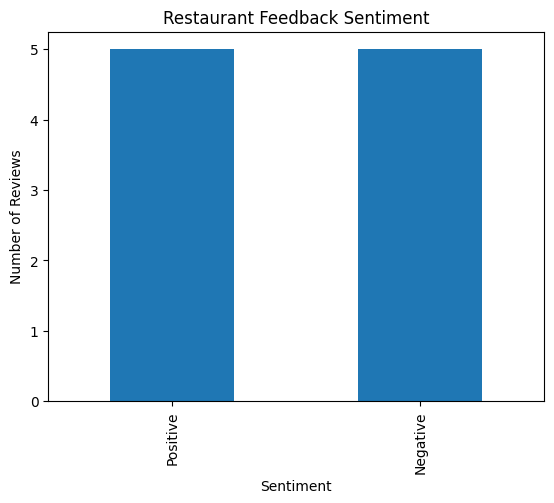

In [10]:

import matplotlib.pyplot as plt

df['Sentiment'].value_counts().plot(kind='bar')

plt.title("Restaurant Feedback Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()


In [11]:
from collections import Counter

all_words = " ".join(df['Clean_Review'])

word_freq = Counter(all_words.split())

print(word_freq.most_common(15))


[('food', 4), ('delivery', 3), ('packaging', 2), ('customer', 2), ('pizza', 1), ('delicious', 1), ('fast', 1), ('arrived', 1), ('cold', 1), ('damaged', 1), ('excellent', 1), ('service', 1), ('tasty', 1), ('late', 1), ('quality', 1)]


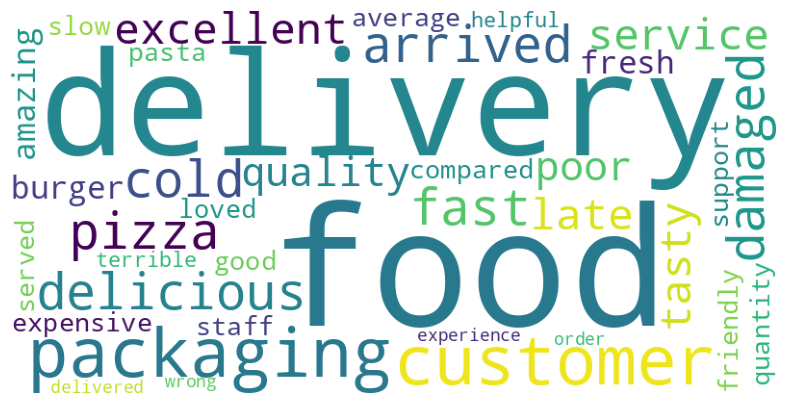

In [12]:

from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()


In [13]:

negative_reviews = df[df['Sentiment']=="Negative"]

negative_reviews

,Review,Clean_Review,Sentiment
1,Food arrived cold and the packaging was damaged.,food arrived cold packaging damaged,Negative
3,Delivery was late and food quality was poor.,delivery late food quality poor,Negative
5,Very expensive compared to the quantity served.,expensive compared quantity served,Negative
8,Food was average but customer support was help...,food average customer support helpful,Negative
9,"Terrible experience, wrong order delivered.",terrible experience wrong order delivered,Negative


In [14]:

print(df['Sentiment'].value_counts())

Sentiment
Positive    5
Negative    5
Name: count, dtype: int64


In [15]:
print("\nRestaurant Feedback Insights")
print("--------------------------------")

positive_count = len(df[df['Sentiment'] == 'Positive'])
negative_count = len(df[df['Sentiment'] == 'Negative'])

print("Total Positive Reviews :", positive_count)
print("Total Negative Reviews :", negative_count)

print("\nCommon Positive Areas:")
print("- Delicious food")
print("- Good taste and presentation")
print("- Fast delivery")
print("- Friendly staff")
print("- Value for money")

print("\nCommon Customer Complaints:")
print("- Delayed delivery")
print("- Cold food")
print("- Poor customer service")
print("- Damaged packaging")
print("- Ignored customer complaints")

print("\nRecommendations:")
print("- Improve delivery speed")
print("- Enhance food packaging quality")
print("- Train customer support staff")
print("- Ensure food freshness before dispatch")
print("- Respond quickly to customer complaints")


Restaurant Feedback Insights
--------------------------------
Total Positive Reviews : 5
Total Negative Reviews : 5

Common Positive Areas:
- Delicious food
- Good taste and presentation
- Fast delivery
- Friendly staff
- Value for money

Common Customer Complaints:
- Delayed delivery
- Cold food
- Poor customer service
- Damaged packaging
- Ignored customer complaints

Recommendations:
- Improve delivery speed
- Enhance food packaging quality
- Train customer support staff
- Ensure food freshness before dispatch
- Respond quickly to customer complaints
